In [1]:
# Import Required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
from scipy import stats

In [3]:
# Import Dataset
Data=pd.read_csv('Breast_Cancer.csv')

In [4]:
# Size of the data
Data.shape

(569, 33)

In [5]:
# Quick look the dataset
Data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [12]:
# Check the column name
Data.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [13]:
# Check basic information of the data
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
# Check any missung value
Data.isnull().sum()

In [6]:
# Basic statistics summary
Data.describe()
Data.radius_mean.describe()

count    569.000000
mean      14.127292
std        3.524049
min        6.981000
25%       11.700000
50%       13.370000
75%       15.780000
max       28.110000
Name: radius_mean, dtype: float64

C:\Users\Kamely\AppData\Local\Temp\ipykernel_11888\185194055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Data, x='diagnosis',palette=['green', 'blue'])


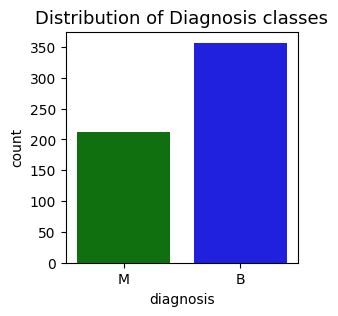

In [28]:
# Frecuency of each categories of Diagnosis column
plt.figure(figsize=(3,3))
sns.countplot(data=Data, x='diagnosis',palette=['green', 'blue'])
plt.xlabel('diagnosis')
plt.ylabel('count')
plt.title('Distribution of Diagnosis classes', fontsize=13)
plt.show()

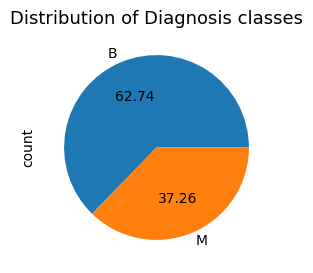

In [ ]:
# Draw Pie chart to know the percentage frequency of Diagnosis classes
plt.figure(figsize=(3,3))
Data['diagnosis'].value_counts().plot(
    kind='pie', 
    autopct='%.2f', )
plt.title('Distribution of Diagnosis classes', fontsize=13)
plt.show()

In [ ]:
# A hist plot (histogram plot) is a type of graph used to visualize the distribution of a numerical (continuous) variable.
# The x-axis represents ranges of values (called bins)
# The y-axis represents the frequency (count)

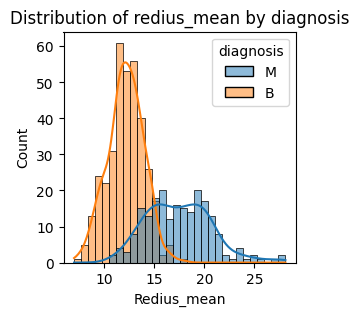

In [38]:
# Redius mean distribution by diagnosis
plt.figure(figsize=(3,3))
sns.histplot(data=Data, 
             x='radius_mean', 
             hue='diagnosis', 
             bins=30, 
             kde=True)
plt.xlabel('Redius_mean')
plt.title('Distribution of redius_mean by diagnosis')
plt.show()

In [ ]:
# Conclusion
# Most frequent malignent redius mean is 20
# Redius mean of malignent tumors is bigger than radius mean of bening tumors mostly.
# Most frequent redius mean is about 14
# The bening distribution is bell shaped

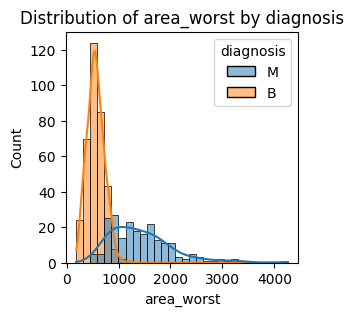

In [42]:
# area_worst distribution by diagnosis
plt.figure(figsize=(3,3))
sns.histplot(data=Data, 
             x='area_worst', 
             hue='diagnosis', 
             bins=30, 
             kde=True)
plt.xlabel('area_worst')
plt.title('Distribution of area_worst by diagnosis')
plt.show()

In [ ]:
# Conclusion
# Most frequent malignent area worst is 1500
# area worst of malignent tumors is bigger than area worst of bening tumors mostly.
# Most frequent area worst is about 400
# The bening distribution is bell shaped

In [ ]:
# Outlier Detection
# Separe Bening Data
Data_Bening=Data[Data['diagnosis']=='B']

# Calculate Quartile range
Q1=Data_Bening['radius_mean'].quantile(0.25) 
Q3=Data_Bening['radius_mean'].quantile(0.50)

# IQR
IQR=Q3-Q1

# Calculate Upper whisker and lower whisker
Lower_w=Q1-1.5*IQR
Upper_w=Q3+1.5*IQR

# Outlier Bening
Oulier_bening=Data_Bening[(Data_Bening['radius_mean']<Lower_w) |
                          (Data_Bening['radius_mean']>Upper_w)
                          ]
# Size of the outlier
Oulier_bening.shape


(80, 33)

C:\Users\Kamely\AppData\Local\Temp\ipykernel_8792\3737415494.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


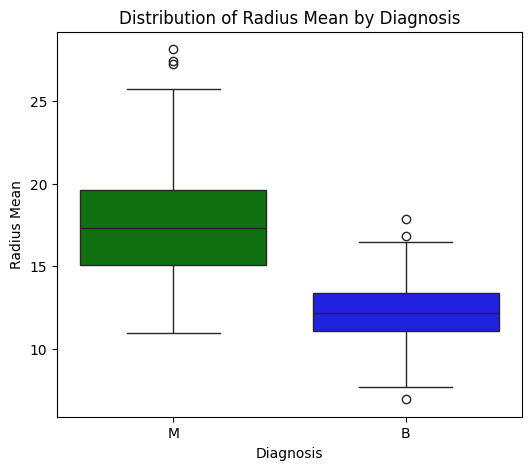

In [ ]:
# Darw boxplot
plt.figure(figsize=(6,5))

sns.boxplot(
    data=Data,
    x='diagnosis',
    y='radius_mean',
    palette=['green', 'blue']
)

plt.xlabel("Diagnosis")
plt.ylabel("Radius Mean")
plt.title("Distribution of Radius Mean by Diagnosis")

plt.show()

C:\Users\Kamely\AppData\Local\Temp\ipykernel_8792\2732215142.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


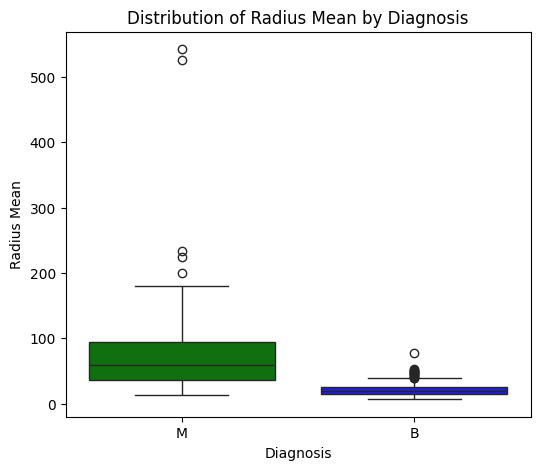

In [ ]:
# Distribution of area_se by diagnosis
plt.figure(figsize=(6,5))

sns.boxplot(
    data=Data,
    x='diagnosis',
    y='area_se',
    palette=['green', 'blue']
)

plt.xlabel("Diagnosis")
plt.ylabel("area_se")
plt.title("Distribution of area_se by Diagnosis")

plt.show()

In [ ]:
# Distribution of radius_mean and redius_worst by diagnosis
Data_long=Data.melt(
    id_vars='diagnosis',
    value_vars=['radius_mean', 'radius_worst'],
    var_name='Feature',
    value_name='Value'
)
Data_long.head()

# melt() converts wide → long (tidy) format.
# A pandas function to reshape data
# Converts columns into rows

,diagnosis,Feature,Value
0,M,radius_mean,17.99
1,M,radius_mean,20.57
2,M,radius_mean,19.69
3,M,radius_mean,11.42
4,M,radius_mean,20.29


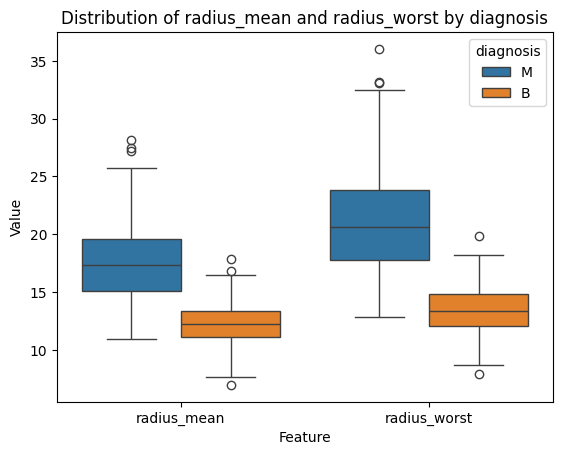

In [32]:
# Draw Box Plot
sns.boxplot(
    data=Data_long,
    x='Feature',
    y='Value',
    hue='diagnosis')
plt.title('Distribution of radius_mean and radius_worst by diagnosis')
plt.show()

In [ ]:
# Conclusion
# we found 3 outlier in benign radius_mean and 2 outlier in benign radius_worst
